Plotting the supercritical case when the thrust is in the right direction

In [1]:
include("sup_elliptical.jl")


sup_opti (generic function with 5 methods)

In [2]:
v=1.75
x_leng=3pi/2
y_leng=3pi/2
div = 200
C = sup_opti(x_leng,y_leng,v,div,true,false,1,false,false)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:  2074240
Number of nonzeros in inequality constraint Jacobian.:    20064
Number of nonzeros in Lagrangian Hessian.............:    57884

Total number of variables............................:   372654
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:   358064
Total number of inequality c

([0.0 0.0 … 0.0 0.0; 1.8995457708724207e-34 3.5465558937028233e-34 … 0.0 0.0; … ; 1.899484439342797e-34 3.546434035350297e-34 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 1.2619786151479594e-33 2.4508569465886218e-33 … 0.0 0.0; … ; 1.262000319941217e-33 2.4508989902342356e-33 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [7.926982050357541e-33 1.4800108820597324e-32 … 1.137619970291863e-14 1.1272230171411835e-14; -1.1169310093417716e-31 -2.272373232833177e-31 … -2.1447416580860915e-5 -2.3051883809207484e-5; … ; -1.1170452596883922e-31 -2.272600457198126e-31 … -2.1447416689948398e-5 -2.305188392324264e-5; 7.926725704495221e-33 1.47996001361363e-32 … 0.0 0.0], [5.26635441145816e-32 1.0227654575934628e-31 … -2.514278602443876e-15 -2.657229586222555e-15; 1.4171371889748889e-30 2.8032638399644455e-30 … 1.1014732873731184e-5 1.1472705182314855e-5; … ; 1.4171593797600776e-30 2.803307690740268e-30 … 1.10147324437449e-5 1.1472704759393232e-5; 5.266444965072048e-32 1.02278299017127e-31 … 3.88522105164701

---
### Measuring thrust and power


In [2]:
# calculate thrust and power 
th = C[7]
pwr = C[13]
ef = th/pwr

print("thrust = ",th, "\nPower = ", pwr,"\nEfficiency = ",ef)

UndefVarError: UndefVarError: `C` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

---
#### Plotting
The supercritical scheme operates with a coordinate transformation where $\tilde{x}=-t$ in order for the scheme to march forward in time rather than backward in $\tilde{x}$. The following code removes this transformation for proper plotting

In [5]:
# div=200
# make a matrix to flip the axes
dom_len = Int64(round(1.75*length(C[3][1,:])))
true_hr = zeros(div+1,dom_len);
true_hi = zeros(div+1,dom_len);
true_qr = zeros(div+1,C[12])
true_qi = zeros(div+1,C[12]);

n = length(C[3][1,:])
for i in 1:length(C[3][1,:])
    # true_qr[:,i] = C[1][:,n-i+1]
    # true_qi[:,i] = C[2][:,n-i+1]
    true_hr[:,i] = C[3][:,n-i+1]
    true_hi[:,i] = C[4][:,n-i+1]
end
true_xvals = zeros(dom_len)
end_index = 4*C[12]
for i in 1:dom_len
    true_xvals[i] = -C[5][end_index] + (i-1)*C[8] + x_leng/2
end

for i in 1:C[12]
    true_qr[:,i] = C[1][:,C[12]-i+1]
    true_qi[:,i] = C[2][:,C[12]-i+1]
end
q_xvals = zeros(C[12])
for i in 1:C[12]
    q_xvals[i] = -x_leng/2 + (i-1)*C[8]
end

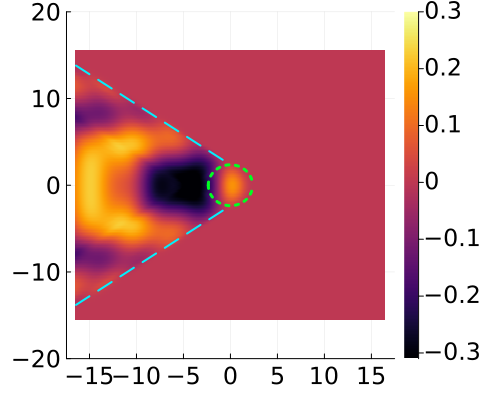

In [ ]:
# define circle that the source is defined over.
r = 3pi/4
circ_x = -r:0.01:r
circ_plus = []
circ_minus = []
for i in 1:length(circ_x)
    append!(circ_plus, sqrt(r^2 - circ_x[i]^2))
    append!(circ_minus, -sqrt(r^2 - circ_x[i]^2))
end

# making wedge branches based off of the characteristics
lhs_x = true_xvals[1]
lhs_y = C[6][1]
gamma = 1/sqrt(v^2-1)
x_line = lhs_x+C[8]:0.01:0
y_low = zeros(length(x_line))
y_up = zeros(length(x_line))
z_line = zeros(length(x_line))
for i in 1:length(z_line)
    z_line[i] -= 0.6
    y_low[i] = gamma*x_line[i] - r
    y_up[i] = -gamma*x_line[i] + r
end



theme(:default)
plt=heatmap(true_xvals,C[6],true_hr,tickfontsize=16,right_margin=0.75Plots.cm,clims=(-0.31,0.3),size=(480,400),ylims=[-20,20])
plot!(plt,circ_x,circ_plus,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(plt,circ_x,circ_minus,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)
plot!(plt, x_line, y_low,legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
plot!(plt, x_line, y_up, legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
# savefig(plt,"sup_v15.pdf")

In [ ]:
# can plot as a surface to show the wedge more clearly
plt=surface(true_xvals,C[6],true_hr,tickfontsize=16,size=(1000,1000),camera=(0,90))
plot!(plt, x_line, y_low,z_line,legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
plot!(plt, x_line, y_up,z_line,legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)


---

### Widening the domain


Sometimes the domain is not wide enough to maintain the same aspect ratio so we can make a wider one, eg for v=1.75 we can put it into a matrix of width 301 to get past -20,20


In [12]:
wider_hr = zeros(301,dom_len)
for i in 1:201
    for j in 1:dom_len
        wider_hr[i+51,j] = true_hr[i,j]
    end
end
new_yvals = zeros(301)
for i in 1:301
    new_yvals[i] = C[6][1]-(50*C[9])+(i-1)*C[9]
end


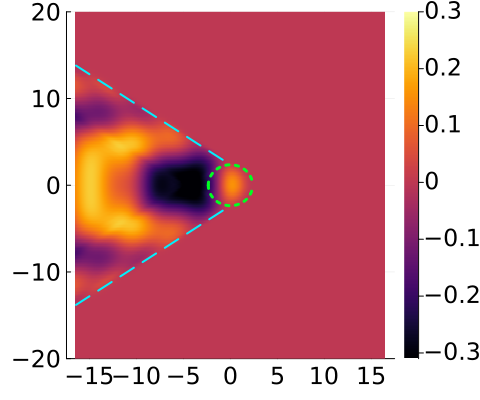

In [ ]:
plt=heatmap(true_xvals,new_yvals,wider_hr,tickfontsize=16,right_margin=0.75Plots.cm,clims=(-0.31,0.3),size=(480,400),ylims=[-20,20])
plot!(plt,circ_x,circ_plus,label=false,color="#00ff22",linestyle=:dot,
        linewidth=3)
plot!(plt,circ_x,circ_minus,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=3)
plot!(plt, x_line, y_low,legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)
plot!(plt, x_line, y_up, legend=false,color="#00f1ff",linewidth=2,
            linestyle=:dash)

---

#### Plotting the source

In [16]:
lhs_x = true_xvals[1]
lhs_y = C[6][1]

proj_hr = copy(true_hr)
proj_hi = copy(true_hi)

proj_qr = copy(true_qr)
proj_qi = copy(true_qi)

a = x_leng/2
b = y_leng/2

dx = C[8]
dy = C[9]

for xi in 1:length(true_hr[1,:])
	for yi in 1:length(true_hr[:,1])
		# check if it is in the ellipse
		x = lhs_x + (xi-1)*dx # minus one because we start xi at 1
		y = lhs_y + (yi-1)*dy
		if (x/a)^2 + (y/b)^2 > 1
			proj_hr[yi,xi] = NaN
            proj_hi[yi,xi] = NaN
		else
            # true_hi[yi,xi] = NaN
			# true_hr[yi,xi] = NaN
		end
	end	
end

for xi in 1:length(true_qr[1,:])
	for yi in 1:length(true_qr[:,1])
		# check if it is in the ellipse
		x = q_xvals[1] + (xi-1)*dx # minus one because we start xi at 1
		y = C[6][1] + (yi-1)*dy
		if (x/a)^2 + (y/b)^2 >= 1-dx
			proj_qr[yi,xi] = NaN
            proj_qi[yi,xi] = NaN
		else
            # true_hi[yi,xi] = NaN
			# true_hr[yi,xi] = NaN
		end
	end	
end

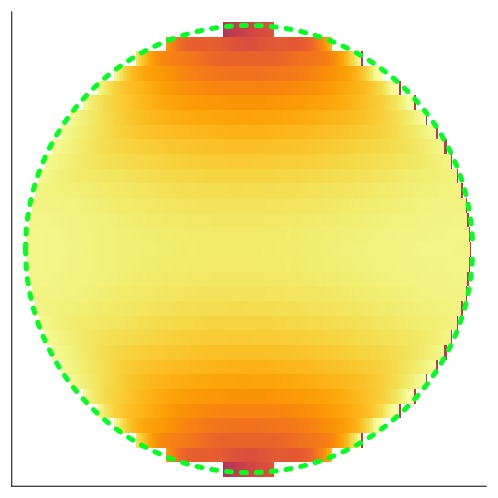

In [19]:
qplt = heatmap(q_xvals, C[6],proj_qr,clims=(-0.31,0.3),ylims=[-2.5,2.5],xlims=[-2.5,2.5],
        colorbar=false,size=(500,500),xticks=false,yticks=false)
plot!(qplt,circ_x,circ_plus,label=false,color="#00ff22",linestyle=:dot,
        linewidth=5)
plot!(qplt,circ_x,circ_minus,label=false,color="#00ff22",linestyle=:dot,  
        linewidth=5)
# savefig(qplt,"v175_source.pdf")

----
#### Use JLD2 for data saving

In [ ]:
# using JLD2
# info = "divs = 400 run at v=1.25 so that the wedge is better resolved (thrust sign fix)"
# info2 = "use post processing to make right orientation, saved true_hr for reference"
# jldsave("sup_v125_1407.jld2"; info, info2, C, true_xvals,true_hr, r)

---